In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Find project root by looking for a known marker (requirements.txt)
def find_project_root(marker="requirements.txt"):
    current = Path.cwd().resolve()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find {marker} in any parent directory")

PROJECT_ROOT = find_project_root()
DATA_RAW = PROJECT_ROOT / "data" / "raw"

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path:    {DATA_RAW}")
print(f"CSV exists:   {(DATA_RAW / 'season_2024_results.csv').exists()}")

# Plot styling
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["figure.dpi"] = 100

Project root: /Users/ompatil9819gmail.com/F1-Race-Predictor
Data path:    /Users/ompatil9819gmail.com/F1-Race-Predictor/data/raw
CSV exists:   True


In [9]:
df = pd.read_csv(DATA_RAW / "season_2024_results.csv")
print(f"Shape: {df.shape}")
print(f"Rounds: {df['Round'].nunique()}, Drivers: {df['Abbreviation'].nunique()}")
df.head()

Shape: (479, 27)
Rounds: 24, Drivers: 24


,DriverNumber,BroadcastName,Abbreviation,DriverId,TeamName,TeamColor,TeamId,FirstName,LastName,FullName,...,Q3,Time,Status,Points,Laps,Year,Round,EventName,EventDate,Circuit
0,1,M VERSTAPPEN,VER,max_verstappen,Red Bull Racing,3671c6,red_bull,Max,Verstappen,Max Verstappen,...,NaN,0 days 01:31:44.742000,Finished,26.0,57.0,2024,1,Bahrain Grand Prix,2024-03-02,Sakhir
1,11,S PEREZ,PER,perez,Red Bull Racing,3671c6,red_bull,Sergio,Perez,Sergio Perez,...,NaN,0 days 00:00:22.457000,Finished,18.0,57.0,2024,1,Bahrain Grand Prix,2024-03-02,Sakhir
2,55,C SAINZ,SAI,sainz,Ferrari,e8002d,ferrari,Carlos,Sainz,Carlos Sainz,...,NaN,0 days 00:00:25.110000,Finished,15.0,57.0,2024,1,Bahrain Grand Prix,2024-03-02,Sakhir
3,16,C LECLERC,LEC,leclerc,Ferrari,e8002d,ferrari,Charles,Leclerc,Charles Leclerc,...,NaN,0 days 00:00:39.669000,Finished,12.0,57.0,2024,1,Bahrain Grand Prix,2024-03-02,Sakhir
4,63,G RUSSELL,RUS,russell,Mercedes,27f4d2,mercedes,George,Russell,George Russell,...,NaN,0 days 00:00:46.788000,Finished,10.0,57.0,2024,1,Bahrain Grand Prix,2024-03-02,Sakhir


In [10]:
print("Missing values:")
print(df[["Position", "GridPosition", "Points", "Status"]].isna().sum())
print("\nFinish status breakdown:")
print(df["Status"].value_counts().head(10))

Missing values:
Position         0
GridPosition    20
Points          20
Status          20
dtype: int64

Finish status breakdown:
Status
Finished         275
Lapped           130
Retired           49
Did not start      3
Disqualified       2
Name: count, dtype: int64


In [11]:
# Position is NaN for DNFs; GridPosition can be 0 for pit lane starts
df["Points"] = pd.to_numeric(df["Points"], errors="coerce").fillna(0)
df["GridPosition"] = pd.to_numeric(df["GridPosition"], errors="coerce")
df["Position"] = pd.to_numeric(df["Position"], errors="coerce")
df["Finished"] = df["Position"].notna()

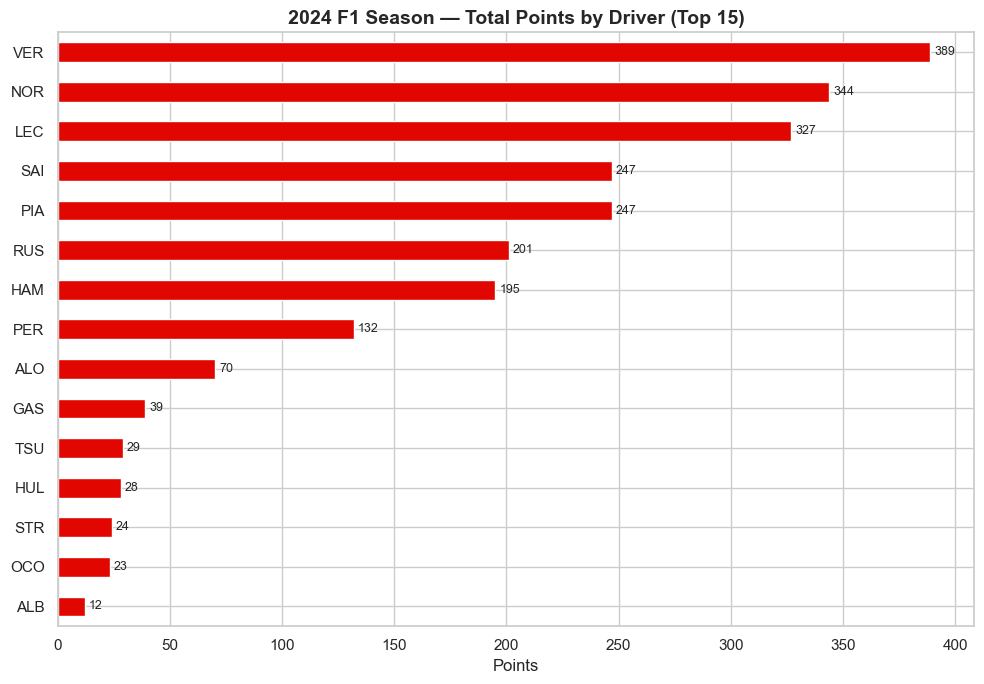

In [12]:
points_by_driver = (
    df.groupby("Abbreviation")["Points"]
      .sum()
      .sort_values(ascending=True)
      .tail(15)  # top 15
)

fig, ax = plt.subplots(figsize=(10, 7))
points_by_driver.plot(kind="barh", ax=ax, color="#E10600")  # F1 red
ax.set_title("2024 F1 Season — Total Points by Driver (Top 15)", fontsize=14, fontweight="bold")
ax.set_xlabel("Points")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_points_by_driver.png", dpi=120, bbox_inches="tight")
plt.show()

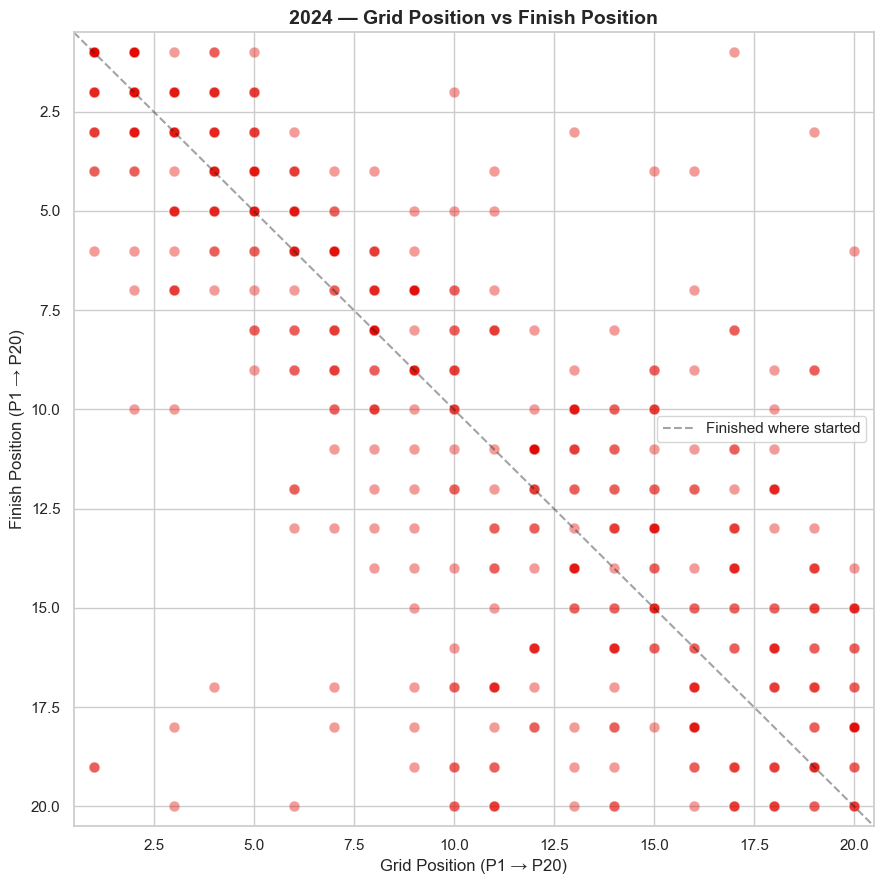

Pearson correlation (Grid vs Finish): 0.736


In [16]:
# Prepare the plotting data
plot_df = df.dropna(subset=["GridPosition", "Position"]).copy()
plot_df = plot_df[plot_df["GridPosition"] > 0]  # exclude pit-lane starts

# Build the plot
fig, ax = plt.subplots(figsize=(9, 9))
sns.scatterplot(
    data=plot_df, x="GridPosition", y="Position",
    alpha=0.4, s=60, color="#E10600", ax=ax
)
lim = [0.5, 20.5]
ax.plot(lim, lim, "k--", alpha=0.4, label="Finished where started")
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.invert_yaxis()  # only invert y so P1 is top, P20 bottom
ax.set_xlabel("Grid Position (P1 → P20)")
ax.set_ylabel("Finish Position (P1 → P20)")
ax.set_title("2024 — Grid Position vs Finish Position", fontsize=14, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_grid_vs_finish.png", dpi=120, bbox_inches="tight")
plt.show()

# Quantify the relationship
corr = plot_df[["GridPosition", "Position"]].corr().iloc[0, 1]
print(f"Pearson correlation (Grid vs Finish): {corr:.3f}")

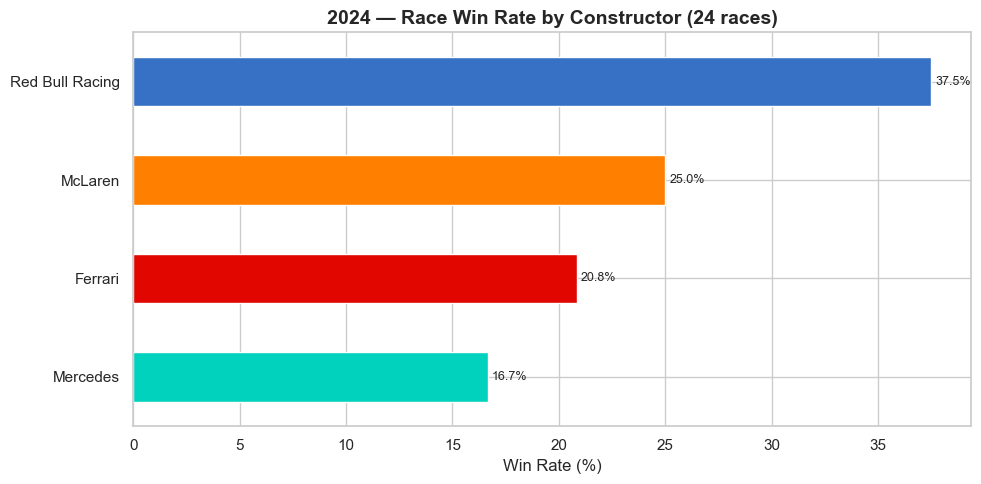


Win counts:
TeamName
Red Bull Racing    9
McLaren            6
Ferrari            5
Mercedes           4
Name: count, dtype: int64


In [19]:
wins = df[df["Position"] == 1]
constructor_wins = wins["TeamName"].value_counts()
total_races = df["Round"].nunique()
win_rate = (constructor_wins / total_races * 100).sort_values(ascending=True)

# Official 2024 team colours, mapped by name
TEAM_COLORS = {
    "Red Bull Racing": "#3671C6",   
    "Ferrari":         "#E10600",   
    "McLaren":         "#FF8000",   
    "Mercedes":        "#00D2BE",   
    "Aston Martin":    "#229971",
    "Alpine":          "#0093CC",
    "Williams":        "#64C4FF",
    "RB":              "#6692FF",
    "Kick Sauber":     "#52E252",
    "Haas F1 Team":    "#B6BABD",
}

# Pull colours in the same order as the bars (matches win_rate's index)
bar_colors = [TEAM_COLORS.get(team, "#888888") for team in win_rate.index]

fig, ax = plt.subplots(figsize=(10, 5))
win_rate.plot(kind="barh", ax=ax, color=bar_colors)
ax.set_title(f"2024 — Race Win Rate by Constructor ({total_races} races)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Win Rate (%)")
ax.set_ylabel("")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3, fontsize=9)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks" / "chart_constructor_winrate.png", dpi=120, bbox_inches="tight")
plt.show()

print("\nWin counts:")
print(constructor_wins)

In [20]:
print("=" * 50)
print("2024 SEASON SUMMARY")
print("=" * 50)
print(f"Races analysed:      {df['Round'].nunique()}")
print(f"Unique drivers:      {df['Abbreviation'].nunique()}")
print(f"Constructors:        {df['TeamName'].nunique()}")
print(f"DNFs:                {(~df['Finished']).sum()} ({(~df['Finished']).mean()*100:.1f}%)")
print(f"Pole-to-win conversions: "
      f"{((df['GridPosition'] == 1) & (df['Position'] == 1)).sum()} / "
      f"{(df['GridPosition'] == 1).sum()}")
print(f"\nGrid→Finish correlation: {corr:.3f}")

2024 SEASON SUMMARY
Races analysed:      24
Unique drivers:      24
Constructors:        10
DNFs:                0 (0.0%)
Pole-to-win conversions: 11 / 23

Grid→Finish correlation: 0.736
